# Subsurface temperature structure of the Blob in FOSI

### 0. Set up

In [1]:
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools
import glob

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
import json 
from IPython.utils import io
from os.path import exists
from scipy.stats import gaussian_kde
import seaborn as sns
import netCDF4 as nc4
from scipy import interpolate

### 0.1 Functions

In [2]:
def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [3]:
# Accessing glade CESM LENS2
def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']

    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()

    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])

        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])

    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)

    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)

    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices

def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths,
                                 concat_dim='time',
                                 combine='nested',
                                 parallel=True)
    return var_ds

In [4]:
def setup_axes(ax): # from Jacob's notebook
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def lons_to_360(data, coord='lon'): # from Jacob's notebook
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data

def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

def pop_find_lat_ind(loc, LATDAT): # from Anna's notebook
    return np.abs(LATDAT[:, 0].values - loc).argmin()

def pop_find_lon_ind(loc, LONDAT, direction="w"): # from Anna's notebook
    if direction.lower() in ["east", "e"]:
        value = loc
    elif direction.lower() in ["west", "w"]:
        value = 360 - loc
    else:
        print("I do not know which direction.")
    return np.nanargmin(np.abs(LONDAT[0, :].values - value))

In [5]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])

    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)

    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})

    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})

    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])

    # compute anomalies by removing all  the model coefficients
    ssta_notrend = sst-model_da.dot(sst_mod)

    # Use the 90th percentile as a threshold and find anomalies that exceed it.
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})

    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])

    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)

    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)})
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})

    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})

    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])

    # compute anomalies by removing all  the model coefficients
    ssta_notrend = sst-model_da.dot(sst_mod)

    # Use the 90th percentile as a threshold and find anomalies that exceed it.
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})

    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

def calculate_anomalies_trend_features_4d_with_trend(ds):
    """
    Calculate anomalies, trends, and features for 4D data (time × z_t × lat × lon)

    Parameters:
    ds : xarray.DataArray
        Input data with dimensions (time, z_t, lat, lon)

    Returns:
    mean, trend, seas, features_notrend, ssta_notrend
        All outputs will preserve z_t dimension
    """
    # Ensure we have all required dimensions
    if 'z_t' not in ds.dims:
        raise ValueError("Input data must have 'z_t' dimension")

    # Convert time to decimal years for harmonic analysis
    dyr = ds.time.dt.year + ds.time.dt.month/12

    # Create the 6-coefficient model matrix
    model = np.array([
        np.ones(len(dyr)),
        dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr),
        np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr),
        np.cos(4*np.pi*dyr)
    ])
    # Pseudo-inverse for least squares solution
    pmodel = np.linalg.pinv(model)

    # Convert to DataArrays
    model_da = xr.DataArray(
        model.T,
        dims=['time', 'coeff'],
        coords={'time': ds.time, 'coeff': np.arange(1, 7)}
    )

    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(1, 7), 'time': ds.time}
    )

    # Calculate coefficients for each depth level
    # Note: This is the key 4D modification - we now dot product with 4D data
    coeffs = xr.dot(pmodel_da, ds)  # Result has dims (coeff, z_t, lat, lon)

    # Construct components (now includes z_t)
    mean = model_da[:, 0].dot(coeffs.sel(coeff=1))  # dims: (z_t, lat, lon)
    trend = model_da[:, 1].dot(coeffs.sel(coeff=2))  # dims: (z_t, lat, lon)
    seas = model_da[:, 2:].dot(coeffs.sel(coeff=slice(3, 6)))  # dims: (time, z_t, lat, lon)

    # Compute full model prediction and anomalies
    full_model = model_da.dot(coeffs)  # dims: (time, z_t, lat, lon)
    ssta_with_trend = ds - full_model + mean

    # Handle chunking if data is dask array
    if ssta_with_trend.chunks:
        ssta_with_trend = ssta_notrend.chunk({'time': -1, 'z_t': -1})

    # Calculate 90th percentile threshold for each depth level
    threshold = ssta_with_trend.quantile(0.9, dim=('time'))  # dims: (z_t, lat, lon)

    # Find features exceeding threshold
    features_withtrend = ssta_with_trend.where(ssta_with_trend >= threshold)

    return mean, trend, seas, features_withtrend, ssta_with_trend

def calculate_anomalies_trend_features_4d(ds):
    """
    Calculate anomalies, trends, and features for 4D data (time × z_t × lat × lon)
    
    Parameters:
    ds : xarray.DataArray
        Input data with dimensions (time, z_t, lat, lon)
        
    Returns:
    mean, trend, seas, features_notrend, ssta_notrend
        All outputs will preserve z_t dimension
    """
    # Ensure we have all required dimensions
    if 'z_t' not in ds.dims:
        raise ValueError("Input data must have 'z_t' dimension")
    
    # Convert time to decimal years for harmonic analysis
    dyr = ds.time.dt.year + ds.time.dt.month/12
    
    # Create the 6-coefficient model matrix
    model = np.array([
        np.ones(len(dyr)),
        dyr - np.mean(dyr),
        np.sin(2*np.pi*dyr),
        np.cos(2*np.pi*dyr),
        np.sin(4*np.pi*dyr),
        np.cos(4*np.pi*dyr)
    ])
    
    # Pseudo-inverse for least squares solution
    pmodel = np.linalg.pinv(model)
        
    # Convert to DataArrays
    model_da = xr.DataArray(
        model.T,
        dims=['time', 'coeff'],
        coords={'time': ds.time, 'coeff': np.arange(1, 7)}
    )
    
    pmodel_da = xr.DataArray(
        pmodel.T,
        dims=['coeff', 'time'],
        coords={'coeff': np.arange(1, 7), 'time': ds.time}
    )
    
    # Calculate coefficients for each depth level
    # Note: This is the key 4D modification - we now dot product with 4D data
    coeffs = xr.dot(pmodel_da, ds)  # Result has dims (coeff, z_t, lat, lon)
    
    # Construct components (now includes z_t)
    mean = model_da[:, 0].dot(coeffs.sel(coeff=1))  # dims: (z_t, lat, lon)
    trend = model_da[:, 1].dot(coeffs.sel(coeff=2))  # dims: (z_t, lat, lon)
    seas = model_da[:, 2:].dot(coeffs.sel(coeff=slice(3, 6)))  # dims: (time, z_t, lat, lon)
    
    # Compute full model prediction and anomalies
    full_model = model_da.dot(coeffs)  # dims: (time, z_t, lat, lon)
    ssta_notrend = ds - full_model
    
    # Handle chunking if data is dask array
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1, 'z_t': -1})

    # Calculate 90th percentile threshold for each depth level
    threshold = ssta_notrend.quantile(0.9, dim=('time'))  # dims: (z_t, lat, lon)
    
    # Find features exceeding threshold
    features_notrend = ssta_notrend.where(ssta_notrend >= threshold)
    
    return mean, trend, seas, features_notrend, ssta_notrend

### 0.2 Loading data

In [6]:
#### CESM LENS2 for GRIDDING PURPOSES
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [7]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)

mhw_obj_mask = mask_3
# fosi_blobs = xr.open_dataset('fosi_blobs.nc').labels
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc') # 112 final events

In [8]:
#### FOSI
firstyear = 1979
lastyear = 2020

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

In [9]:
field = 'TEMP'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_temp = xr.open_dataset(fpath+fname)[field].isel(z_t=slice(0, 20))

In [10]:
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi_temp['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi_temp[ds_smyle_fosi_temp.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [11]:
fosi_anom_1deg_wzeros_temp = regrid_SMYLE(ds_smyle_fosi_temp)

In [12]:
fosi_anom_1deg_temp = fosi_anom_1deg_wzeros_temp.where(fosi_anom_1deg_wzeros_temp!=0, np.nan)

regridder_temp = xe.Regridder(fosi_anom_1deg_temp.sel(time=slice('1979-01-01','2020-12-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded_temp = regridder_temp(fosi_anom_1deg_temp.sel(time=slice('1979-01-01','2020-12-01')))

In [13]:
# regridded_temp_in_mask_region = regridded_temp*mhw_obj_mask
smaller_region_temp = regridded_temp.sel(lat = slice(12, 65), lon=slice(155, 245))

mean, trend, seas, features, anomalies = calculate_anomalies_trend_features_4d(smaller_region_temp)

/glade/u/apps/opt/conda/envs/npl-2025a/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [14]:
# mean_wt, trend_wt, seas_wt, features_withtrend_wt, ssta_with_trend_wt = calculate_anomalies_trend_features_4d_with_trend(smaller_region_temp)

In [15]:
smaller_mhw_obj_mask = mhw_obj_mask.sel(lat = slice(12, 65), lon=slice(155, 245))

In [16]:
anomalies_region = smaller_mhw_obj_mask*anomalies

In [17]:
anomalies_region_nan = xr.where(anomalies_region == 0., np.nan, anomalies_region)

In [54]:
field = 'HMXL'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_hxml = xr.open_dataset(fpath+fname)[field]

In [55]:
ds_smyle_fosi_hxml['time'] = fosi_montime_vals
fosi_mld = ds_smyle_fosi_hxml[ds_smyle_fosi_hxml.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

In [56]:
fosi_anom_1deg_wzeros_mld = regrid_SMYLE(fosi_mld)

In [57]:
fosi_anom_1deg_mld = fosi_anom_1deg_wzeros_mld.where(fosi_anom_1deg_wzeros_mld!=0, np.nan)

regridder_mld = xe.Regridder(fosi_anom_1deg_mld.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded_mld = regridder_mld(fosi_anom_1deg_mld.sel(time=slice('1979-01-01','2021-01-01')))

In [58]:
mld_region = (smaller_mhw_obj_mask*regridded_mld)/100

In [59]:
mld_region_nan = mld_region.where(mld_region!=0, np.nan)


In [60]:
print(mask_3.lat.min().values, mask_3.lat.max().values)
print(mask_3.lon.min().values, mask_3.lon.max().values)

-64.55497382198953 69.26701570680628
0.0 358.75


In [24]:
# Crop fosi_blobs to match anomalies' cropped region, get blob_times
object_id = 94.0
fosi_blobs_cropped = fosi_blobs.labels.sel(lat=slice(12, 65), lon=slice(155, 245))

blob_times = fosi_blobs_cropped.time.where(
    (fosi_blobs_cropped == object_id).any(dim=('lat', 'lon')), drop=True
)
print(f"n_months in blob_times: {len(blob_times)} -- VERIFY: 20")

# Build padded time window (±2 months)
full_time_index = anomalies.time
first_idx = int(np.where(full_time_index.values == blob_times.values[0])[0][0])
last_idx = int(np.where(full_time_index.values == blob_times.values[-1])[0][0])
pad_start = max(0, first_idx - 2)
pad_end = min(len(full_time_index) - 1, last_idx + 2)
padded_times = full_time_index.isel(time=slice(pad_start, pad_end + 1))

# mask with fixed smaller_mhw_obj_mask, all months
canonical_masked = anomalies.sel(time=padded_times).where(smaller_mhw_obj_mask == 1)
canonical_profile = canonical_masked.mean(dim=('lat', 'lon')).compute()

first_mask = (fosi_blobs_cropped.sel(time=blob_times.values[0]) == object_id).reset_coords('time', drop=True)
last_mask = (fosi_blobs_cropped.sel(time=blob_times.values[-1]) == object_id).reset_coords('time', drop=True)

tv_profile_list = []
for t in padded_times.values:
    if t in blob_times.values:
        m = (fosi_blobs_cropped.sel(time=t) == object_id).reset_coords('time', drop=True)
    elif t < blob_times.values[0]:
        m = first_mask
    else:
        m = last_mask
    month_anom = anomalies.sel(time=t).where(m).mean(dim=('lat', 'lon'))  # <-- .mean(...) restored
    tv_profile_list.append(month_anom.assign_coords(time=t))

tv_profile = xr.concat(tv_profile_list, dim='time')
print("tv_profile dims:", tv_profile.dims, tv_profile.shape, "-- expect (time, z_t)")

n_months in blob_times: 20 -- VERIFY: 20
tv_profile dims: ('time', 'z_t') (24, 20) -- expect (time, z_t)


In [30]:
def compute_depth_of_reach(profile, threshold=1.):
    """profile: (time, z_t) DataArray of subsurface anomaly. Returns the deepest
    level (in meters) at which the anomaly exceeds `threshold` at any point
    during the event's padded window."""
    exceeds = profile > threshold
    if not exceeds.any():
        return 0.0
    depths_exceeded = profile.z_t.where(exceeds.any(dim='time'), drop=True)
    return float(depths_exceeded.max()) / 100  # cm to m

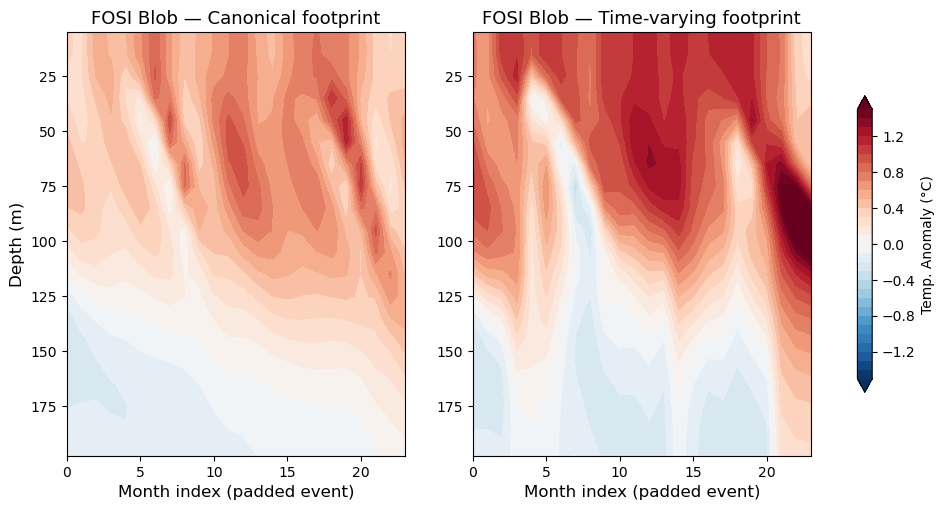

Canonical depth-of-reach: 75.0m
Time-varying depth-of-reach: 115.0m


In [39]:
# Step 6: Plot canonical vs. time-varying, side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
levels = np.linspace(-1.5, 1.5, 31)

depth_m_canon = canonical_profile.z_t.values / 100
n_time = len(canonical_profile.time)

im0 = axes[0].contourf(np.arange(n_time), depth_m_canon, canonical_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[0].invert_yaxis()
axes[0].set_title('FOSI Blob — Canonical footprint', fontsize=13)
axes[0].set_ylabel('Depth (m)', fontsize=12)
axes[0].set_xlabel('Month index (padded event)', fontsize=12)

im1 = axes[1].contourf(np.arange(n_time), depth_m_canon, tv_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[1].invert_yaxis()
axes[1].set_title('FOSI Blob — Time-varying footprint', fontsize=13)
axes[1].set_xlabel('Month index (padded event)', fontsize=12)

cbar = fig.colorbar(im0, ax=axes, label='Temp. Anomaly (°C)', shrink=0.7)
plt.savefig('Figure_FOSI_subsurface_canonical_vs_timevarying.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Canonical depth-of-reach: {compute_depth_of_reach(canonical_profile):.1f}m")
print(f"Time-varying depth-of-reach: {compute_depth_of_reach(tv_profile):.1f}m")

In [61]:
# Crop MLD to match anomalies' region, build canonical + time-varying MLD series
smaller_region_mld = regridded_mld.sel(lat=slice(12, 65), lon=slice(155, 245))

# Canonical MLD: masked with fixed footprint, all padded months
canonical_mld_masked = smaller_region_mld.sel(time=padded_times).where(smaller_mhw_obj_mask == 1)
canonical_mld_profile = (canonical_mld_masked.mean(dim=('lat', 'lon')) / 100).compute()  # cm -> m

# Time-varying MLD: masked with the Blob's own tracked footprint per month
tv_mld_list = []
for t in padded_times.values:
    if t in blob_times.values:
        m = (fosi_blobs_cropped.sel(time=t) == object_id).reset_coords('time', drop=True)
    elif t < blob_times.values[0]:
        m = first_mask
    else:
        m = last_mask
    month_mld = smaller_region_mld.sel(time=t).where(m).mean(dim=('lat', 'lon')) / 100  # cm -> m
    tv_mld_list.append(month_mld.assign_coords(time=t))

tv_mld_profile = xr.concat(tv_mld_list, dim='time')

print("Canonical MLD range:", float(canonical_mld_profile.min()), "-", float(canonical_mld_profile.max()), "m")
print("Time-varying MLD range:", float(tv_mld_profile.min()), "-", float(tv_mld_profile.max()), "m")

Canonical MLD range: 27.325742721557617 - 115.44961547851562 m
Time-varying MLD range: 18.51572265625 - 104.029833984375 m


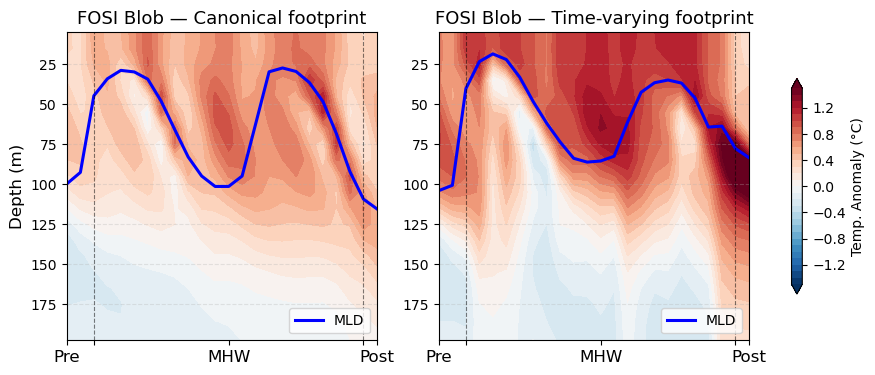

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
levels = np.linspace(-1.5, 1.5, 31)

depth_m_canon = canonical_profile.z_t.values / 100
n_time = len(canonical_profile.time)
x = np.arange(n_time)

# Define the periods
pre_mhw_end = 2
detection_end = 22

# Create custom x-tick positions and labels
tick_positions = [0, pre_mhw_end, (pre_mhw_end + detection_end)//2, detection_end, n_time-1]
tick_labels = ['Pre', '', 'MHW', '', 'Post']

# First subplot
im0 = axes[0].contourf(x, depth_m_canon, canonical_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[0].invert_yaxis()

# Add MLD line and depth of reach
axes[0].plot(x, canonical_mld_profile.values, color='blue', linewidth=2.2, linestyle='-', label='MLD')
# Add vertical lines
axes[0].axvline(x=pre_mhw_end, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[0].axvline(x=detection_end, color='black', linestyle='--', alpha=0.5, linewidth=0.8)

# Set custom x-ticks and labels
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, fontsize=12)
axes[0].set_title('FOSI Blob — Canonical footprint', fontsize=13)
axes[0].set_ylabel('Depth (m)', fontsize=12)
# axes[0].set_xlabel('Event Phase', fontsize=12)

# Add gridlines
axes[0].grid(axis='y', linestyle='--', alpha=0.3)
axes[0].legend(fontsize=10, loc='lower right')

# Second subplot
# Second subplot
im1 = axes[1].contourf(x, depth_m_canon, tv_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[1].invert_yaxis()

# ADD THIS LINE — it was missing
axes[1].plot(x, tv_mld_profile.values, color='blue', linewidth=2.2, linestyle='-', label='MLD')

# Add vertical lines
axes[1].axvline(x=pre_mhw_end, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axvline(x=detection_end, color='black', linestyle='--', alpha=0.5, linewidth=0.8)

# Set custom x-ticks and labels
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, fontsize=12)
axes[1].set_title('FOSI Blob — Time-varying footprint', fontsize=13)
# axes[1].set_xlabel('Event Phase', fontsize=12)

# Add gridlines
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].legend(fontsize=10, loc='lower right')  # also add legend here, to match axes[0]

cbar = fig.colorbar(im0, ax=axes, label='Temp. Anomaly (°C)', shrink=0.7)
plt.savefig('Figure_FOSI_subsurface_with_MLD_and_depth_reach.png', dpi=300, bbox_inches='tight')
plt.show()

In [75]:
print("tv_mld_profile values:", tv_mld_profile.values)
print("Any NaN?", np.isnan(tv_mld_profile.values).any())
print("All NaN?", np.isnan(tv_mld_profile.values).all())
print("Min/max (ignoring NaN):", np.nanmin(tv_mld_profile.values), np.nanmax(tv_mld_profile.values))

print("\ncanonical_mld_profile values:", canonical_mld_profile.values)

tv_mld_profile values: [104.02983398 100.70428711  40.32090332  23.35078125  18.51572266
  22.03219727  33.13695557  48.41458984  61.92002441  73.67825195
  83.8419043   86.21399414  85.50992188  82.53796875  61.21240234
  42.55437012  36.55614258  34.87559326  36.77387939  46.13146973
  64.2910791   63.70728516  77.71163086  83.40678711]
Any NaN? False
All NaN? False
Min/max (ignoring NaN): 18.51572265625 104.029833984375

canonical_mld_profile values: [ 99.77704   92.64994   44.722694  34.08808   28.822517  29.796946
  34.323708  48.201748  65.84908   83.027145  94.935196 101.45347
 101.43317   94.94371   62.444603  29.737173  27.325743  29.509235
  36.50784   48.358463  68.53366   92.195274 109.339264 115.449615]


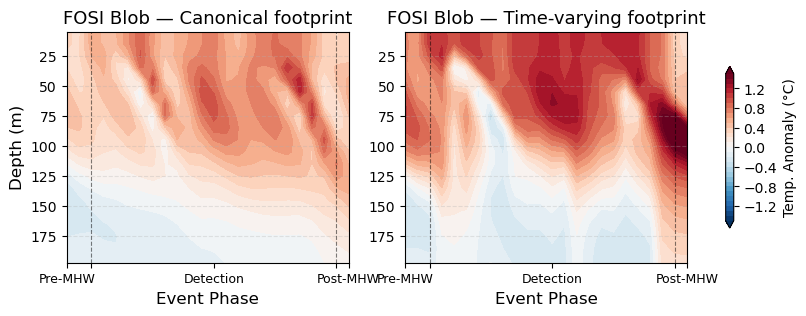

Canonical depth-of-reach: 75.0m
Time-varying depth-of-reach: 115.0m


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
levels = np.linspace(-1.5, 1.5, 31)

depth_m_canon = canonical_profile.z_t.values / 100
n_time = len(canonical_profile.time)

# Define the periods - Detection is now in the middle
pre_mhw_end = 2
detection_start = 2
detection_end = 22  # Detection goes from 2 to 22
post_mhw_start = 22

# Create custom x-tick positions and labels - Detection in the middle
tick_positions = [0, 2, 12, 22, n_time-1]  # 12 is the midpoint of detection period
tick_labels = ['Pre-MHW', '', 'Detection', '', 'Post-MHW']

im0 = axes[0].contourf(np.arange(n_time), depth_m_canon, canonical_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[0].invert_yaxis()
axes[0].set_title('FOSI Blob — Canonical footprint', fontsize=13)
axes[0].set_ylabel('Depth (m)', fontsize=12)
axes[0].set_xlabel('Event Phase', fontsize=12)
# Set custom x-ticks and labels
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, fontsize=9, rotation=0)
# Add vertical lines to separate periods
axes[0].axvline(x=2, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[0].axvline(x=22, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

im1 = axes[1].contourf(np.arange(n_time), depth_m_canon, tv_profile.values.T,
                       levels=levels, cmap='RdBu_r', extend='both')
axes[1].invert_yaxis()
axes[1].set_title('FOSI Blob — Time-varying footprint', fontsize=13)
axes[1].set_xlabel('Event Phase', fontsize=12)
# Set custom x-ticks and labels
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, fontsize=9, rotation=0)
# Add vertical lines to separate periods
axes[1].axvline(x=2, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].axvline(x=22, color='black', linestyle='--', alpha=0.5, linewidth=0.8)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

cbar = fig.colorbar(im0, ax=axes, label='Temp. Anomaly (°C)', shrink=0.7)
plt.savefig('Figure_FOSI_subsurface_canonical_vs_timevarying.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Canonical depth-of-reach: {compute_depth_of_reach(canonical_profile):.1f}m")
print(f"Time-varying depth-of-reach: {compute_depth_of_reach(tv_profile):.1f}m")

In [50]:
def find_depth_of_reach_location(profile, threshold=0.5):
    """Returns (month_index, depth_m) of the deepest point where anomaly exceeds threshold."""
    exceeds = profile > threshold
    if not exceeds.any():
        return None, None
    # For each depth, does ANY month exceed threshold?
    depth_exceeded_mask = exceeds.any(dim='time')
    deepest_z_t = profile.z_t.where(depth_exceeded_mask, drop=True).max().item()
    # Now find WHICH month(s) exceed threshold at that specific depth
    at_deepest = profile.sel(z_t=deepest_z_t)
    month_idx = int(np.where(at_deepest.values > threshold)[0][0])  # first month that crosses it there
    return month_idx, deepest_z_t / 100  # cm to m

canon_month_idx, canon_depth_m = find_depth_of_reach_location(canonical_profile)
tv_month_idx, tv_depth_m = find_depth_of_reach_location(tv_profile)

print(f"Canonical: depth-of-reach {canon_depth_m:.1f}m at month index {canon_month_idx}")
print(f"Time-varying: depth-of-reach {tv_depth_m:.1f}m at month index {tv_month_idx}")

Canonical: depth-of-reach 135.0m at month index 23
Time-varying: depth-of-reach 155.0m at month index 22


In [49]:
blob_area_by_month = []
blob_centroid_lat = []
blob_centroid_lon = []

for t in blob_times.values:
    mask_t = (fosi_blobs_cropped.sel(time=t) == object_id)
    area = float(mask_t.sum())  # gridpoint count as a proxy for area
    blob_area_by_month.append(area)

    if area > 0:
        lat_grid, lon_grid = xr.broadcast(mask_t.lat, mask_t.lon)
        centroid_lat = float(lat_grid.where(mask_t).mean())
        centroid_lon = float(lon_grid.where(mask_t).mean())
    else:
        centroid_lat, centroid_lon = np.nan, np.nan
    blob_centroid_lat.append(centroid_lat)
    blob_centroid_lon.append(centroid_lon)

print("Month-by-month footprint size (gridpoints):")
for i, (t, area) in enumerate(zip(blob_times.values, blob_area_by_month)):
    print(f"  Month {i} ({str(t)[:7]}): area={area:.0f}, centroid=({blob_centroid_lat[i]:.1f}°N, {blob_centroid_lon[i]:.1f}°E)")

Month-by-month footprint size (gridpoints):
  Month 0 (2014-05): area=474, centroid=(45.5°N, 216.8°E)
  Month 1 (2014-06): area=451, centroid=(46.8°N, 205.6°E)
  Month 2 (2014-07): area=334, centroid=(52.4°N, 182.5°E)
  Month 3 (2014-08): area=709, centroid=(48.4°N, 195.4°E)
  Month 4 (2014-09): area=1327, centroid=(41.1°N, 205.0°E)
  Month 5 (2014-10): area=851, centroid=(29.2°N, 208.5°E)
  Month 6 (2014-11): area=428, centroid=(28.0°N, 211.1°E)
  Month 7 (2014-12): area=528, centroid=(38.6°N, 227.5°E)
  Month 8 (2015-01): area=779, centroid=(34.5°N, 225.8°E)
  Month 9 (2015-02): area=1031, centroid=(32.3°N, 224.5°E)
  Month 10 (2015-03): area=1153, centroid=(33.6°N, 223.0°E)
  Month 11 (2015-04): area=866, centroid=(30.3°N, 227.0°E)
  Month 12 (2015-05): area=614, centroid=(36.2°N, 228.7°E)
  Month 13 (2015-06): area=1028, centroid=(31.8°N, 223.3°E)
  Month 14 (2015-07): area=1186, centroid=(28.3°N, 221.2°E)
  Month 15 (2015-08): area=1232, centroid=(28.1°N, 218.1°E)
  Month 16 (2015

In [34]:
print("Current anomalies z_t range:", anomalies.z_t.min().item()/100, "to", anomalies.z_t.max().item()/100, "m")
print("canonical_profile z_t range:", canonical_profile.z_t.min().item()/100, "to", canonical_profile.z_t.max().item()/100, "m")
print("tv_profile z_t range:", tv_profile.z_t.min().item()/100, "to", tv_profile.z_t.max().item()/100, "m")

Current anomalies z_t range: 5.0 to 197.6602734375 m
canonical_profile z_t range: 5.0 to 197.6602734375 m
tv_profile z_t range: 5.0 to 197.6602734375 m


In [27]:
# FOSI Blob's MLD stats
field = 'HMXL'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_hxml = xr.open_dataset(fpath+fname)[field]
ds_smyle_fosi_hxml['time'] = fosi_montime_vals

fosi_mld_raw = ds_smyle_fosi_hxml[ds_smyle_fosi_hxml.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

fosi_mld_1deg_wzeros = regrid_SMYLE(fosi_mld_raw)
fosi_mld_1deg = fosi_mld_1deg_wzeros.where(fosi_mld_1deg_wzeros != 0, np.nan)

regridder_mld = xe.Regridder(fosi_mld_1deg.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded_mld_raw = regridder_mld(fosi_mld_1deg.sel(time=slice('1979-01-01','2021-01-01')))

mld_region_raw = (smaller_mhw_obj_mask * regridded_mld_raw) / 100.0  # cm -> m

In [29]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels
object_id = 94.0
blob_times = fosi_blobs.time.where((fosi_blobs == object_id).any(dim=('lat','lon')), drop=True)

print(f"n_months: {len(blob_times)}")  # should print 20

n_months: 20


In [31]:
fosi_mld_blob_raw = mld_region_raw.sel(time=blob_times)
fosi_mld_blob_masked_raw = fosi_mld_blob_raw.where(mask_3 == 1)

fosi_mld_mean = float(fosi_mld_blob_masked_raw.mean())
fosi_mld_max = float(fosi_mld_blob_masked_raw.max())
fosi_mld_p90 = float(fosi_mld_blob_masked_raw.quantile(0.9))

print(f"FOSI Blob MLD (raw): mean={fosi_mld_mean:.1f}m, max={fosi_mld_max:.1f}m, p90={fosi_mld_p90:.1f}m")

FOSI Blob MLD (raw): mean=57.8m, max=225.7m, p90=103.8m


In [53]:
# Event max: confirm date AND depth
sub = anomalies_region_nan.sel(time=slice('2014-06', '2015-12'))
event_max_val = float(sub.max())

# Find the (time, z_t, lat, lon) location of that max
max_loc = sub.where(sub == sub.max(), drop=True)
print("Event max:", event_max_val)
print("At depth (z_t):", float(max_loc.z_t.values[0]) / 100, "m")  # /100 if z_t is in cm
print("At time:", max_loc.time.values)
print("At lat/lon:", max_loc.lat.values, max_loc.lon.values)

# Area-averaged max: confirm date AND depth
areaavg_3d = anomalies_region_nan.mean(dim=('lat', 'lon'))  # dims: (time, z_t)
areaavg_max_val = float(areaavg_3d.max())

max_loc_2d = areaavg_3d.where(areaavg_3d == areaavg_3d.max(), drop=True)
print("Area-averaged max:", areaavg_max_val)
print("At depth (z_t):", float(max_loc_2d.z_t.values[0]) / 100, "m")
print("At time:", max_loc_2d.time.values)

# Std dev for the ± value, at that same peak depth, over the event duration
peak_depth = float(max_loc_2d.z_t.values[0])
areaavg_at_peak_depth_ts = areaavg_3d.sel(z_t=peak_depth, time=slice('2014-06', '2015-12'))
print("Mean ± std at peak depth over event:", 
      float(areaavg_at_peak_depth_ts.mean()), "±", float(areaavg_at_peak_depth_ts.std()))

Event max: 2.711607418950635
At depth (z_t): 45.0 m
At time: [cftime.DatetimeNoLeap(2015, 9, 15, 0, 0, 0, 0, has_year_zero=True)]
At lat/lon: [46.64921466] [223.75]
Area-averaged max: 1.1672247212596323
At depth (z_t): 45.0 m
At time: [cftime.DatetimeNoLeap(2015, 10, 15, 0, 0, 0, 0, has_year_zero=True)]
Mean ± std at peak depth over event: 0.591354007579869 ± 0.2770793641891412


In [29]:
high_indices = np.where(anomalies_region_nan.sel(
    time=slice('2014-06', '2015-12')) > 2.7)

for idx in zip(*high_indices):
    print(f"Value: {anomalies_region_nan.values[idx]}, at indices: {idx}")

Value: -0.43251635242998354, at indices: (36, 55, 15, 4)


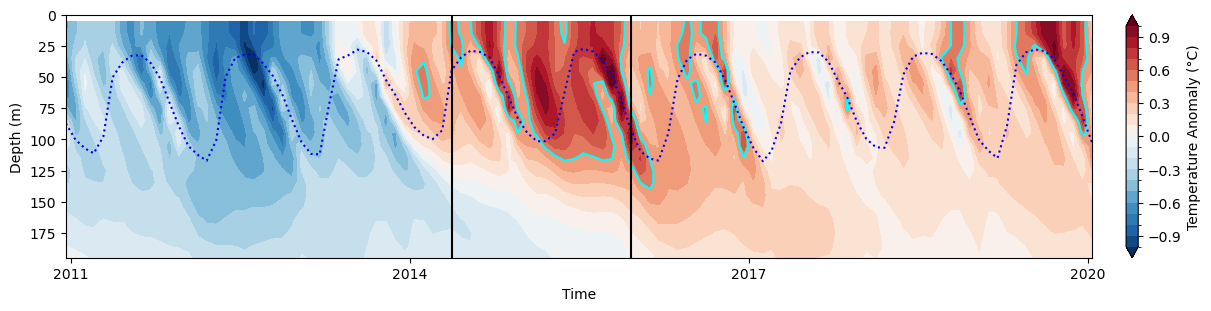

In [36]:
plt.figure(figsize=(12, 3), constrained_layout=True)

data = anomalies_region_nan[:,:].sel(time=slice('2010-12', '2020-01')).mean(dim=('lat','lon')).transpose()
data["z_t"] = data["z_t"] / 100
data["z_t"].attrs["units"] = "m"

# Create contour plot
contour = data.plot.contourf(
    levels=np.linspace(-1., 1., 21),
    vmin=-1.,
    vmax=1.,
    cmap='RdBu_r',
    # cmap=cmocean.cm.thermal,
    add_colorbar=False,
    extend='both'
)

# Create contour plot
contour_lines = data.plot.contour(
    levels=np.linspace(0.5, 1.5, 2),
    vmin=0.5,
    vmax=1.5,
    # cmap=cmocean.cm.balance,
    cmap='cyan',
    add_colorbar=False,
    extend=False,
    # extend='both'
)


# Add colorbar
cbar = plt.colorbar(contour, ax=plt.gca(), pad=0.02)
cbar.set_label('Temperature Anomaly (°C)', fontsize=10)
cbar.ax.tick_params(labelsize=10)

# Format axes
ax = plt.gca()
ax.invert_yaxis()  # Depth increases downward


# # Convert y-axis labels from cm to m
# current_yticks = ax.get_yticks()
# ax.set_yticklabels([f'{int(tick/100)}' for tick in current_yticks])
ax.set_ylabel('Depth (m)', fontsize=10)
ax.set_xlabel('Time', fontsize=10)
# # Date formatting
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[6]))

# Grid and reference lines
# ax.grid(True, which='major', linestyle=':', color='gray', alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.plot(mld_region_nan.mean(dim=('lat','lon')).sel(time=slice('2010-12', '2020-01')).time, 
         mld_region_nan.mean(dim=('lat','lon')).sel(time=slice('2010-12', '2020-01')), 
         c='blue', linestyle='dotted')
# Title

plt.axvline(x = features.time.sel(time='2014-05').item(), c='k')
plt.axvline(x = features.time.sel(time='2015-12').item(), c='k')

# plt.axvline(x = features.time.sel(time='2014-12').item(), c='k')
# plt.axvline(x = features.time.sel(time='2015-11').item(), c='k')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(195, 0)
plt.show()

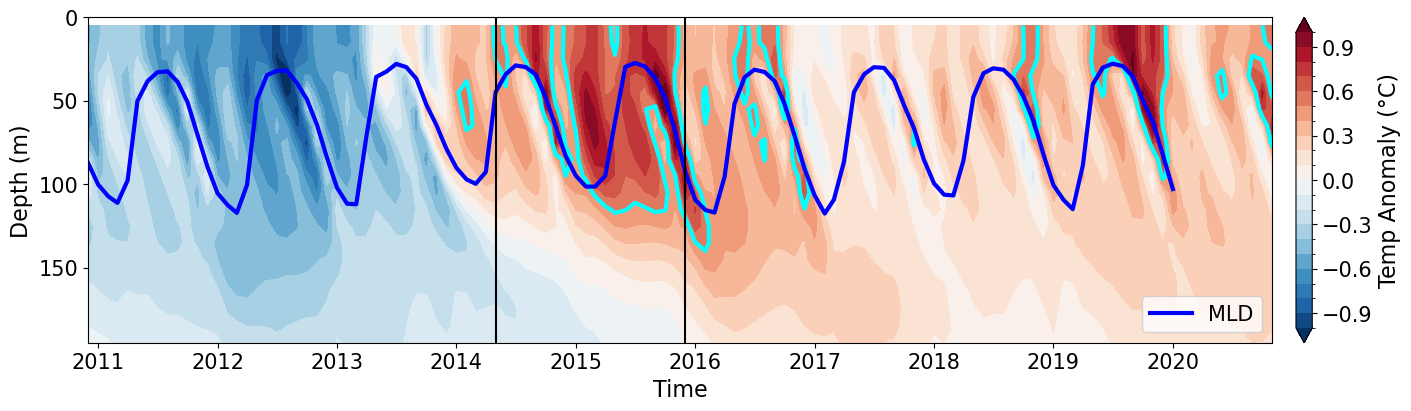

In [55]:
fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)

# Get the data
data = anomalies_region_nan[:, :].sel(time=slice('2010-12', '2020-12')).mean(dim=('lat', 'lon')).transpose()
data["z_t"] = data["z_t"] / 100
data["z_t"].attrs["units"] = "m"

# Filled contour
contour = data.plot.contourf(
    ax=ax,
    levels=np.linspace(-1., 1., 21),
    vmin=-1., vmax=1.,
    cmap='RdBu_r',
    add_colorbar=False,
    extend='both'
)

contour_lines = data.plot.contour(
    ax=ax,
    levels=np.linspace(0.5, 1.5, 2),
    vmin=0.5, vmax=1.5,
    linewidths=3,
    colors='cyan',
    add_colorbar=False,
    extend=False
)

# Colorbar
cbar = plt.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label('Temp Anomaly (°C)', fontsize=16)
cbar.ax.tick_params(labelsize=15)

# Axes formatting
ax.invert_yaxis()
ax.set_ylabel('Depth (m)', fontsize=16)
ax.set_xlabel('Time', fontsize=16)
ax.set_title('')

time_vals = data.time.values
years_present = sorted(set(t.year for t in time_vals))

tick_positions = []
tick_labels = []
for yr in years_present:
    # find the timestamp in time_vals closest to Jan of that year
    jan_candidates = [t for t in time_vals if t.year == yr and t.month == 1]
    if jan_candidates:
        tick_positions.append(jan_candidates[0])
        tick_labels.append(str(yr))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0, ha='center', fontsize=15)
ax.tick_params(axis='y', labelsize=15)

# Reference lines
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

mld_ts = mld_region_nan.mean(dim=('lat', 'lon')).sel(time=slice('2010-12', '2020-01'))
ax.plot(mld_ts.time, mld_ts, c='blue', linewidth=3, label='MLD')

ax.axvline(x=features.time.sel(time='2014-05').item(), c='k', linewidth=1.5)
ax.axvline(x=features.time.sel(time='2015-12').item(), c='k', linewidth=1.5)

ax.legend(fontsize=15, loc='lower right')

ax.set_ylim(195, 0)

plt.show()

In [56]:
sub = anomalies_region_nan.mean(dim=('lat','lon')).sel(time=slice('2014-05','2015-12'))

# For each month, find both peak magnitude AND the max depth where anomaly still exceeds a threshold
print("Month       | Peak SSTa (°C) | Peak depth (m) | Max depth >0.5°C (m)")
for t in sub.time.values:
    profile = sub.sel(time=t)
    peak_val = float(profile.max())
    peak_depth = float(profile.idxmax(dim='z_t')) / 100  # /100 if z_t in cm

    exceeds = profile.where(profile > 0.5, drop=True)
    max_depth_exceeding = float(exceeds.z_t.max())/100 if exceeds.size > 0 else np.nan

    print(f"{str(t)[:7]}   |  {peak_val:.2f}          |  {peak_depth:.0f}            |  {max_depth_exceeding:.0f}")

Month       | Peak SSTa (°C) | Peak depth (m) | Max depth >0.5°C (m)
2014-05   |  0.57          |  5            |  25
2014-06   |  0.54          |  25            |  35
2014-07   |  0.49          |  65            |  nan
2014-08   |  0.67          |  5            |  25
2014-09   |  0.91          |  25            |  35
2014-10   |  0.99          |  45            |  55
2014-11   |  0.83          |  75            |  75
2014-12   |  0.58          |  85            |  85
2015-01   |  0.74          |  35            |  65
2015-02   |  0.95          |  55            |  95
2015-03   |  0.95          |  65            |  105
2015-04   |  0.83          |  85            |  105
2015-05   |  0.70          |  85            |  115
2015-06   |  0.74          |  45            |  115
2015-07   |  0.78          |  65            |  105
2015-08   |  0.82          |  15            |  105
2015-09   |  1.08          |  35            |  115
2015-10   |  1.17          |  45            |  115
2015-11   |  1.06       

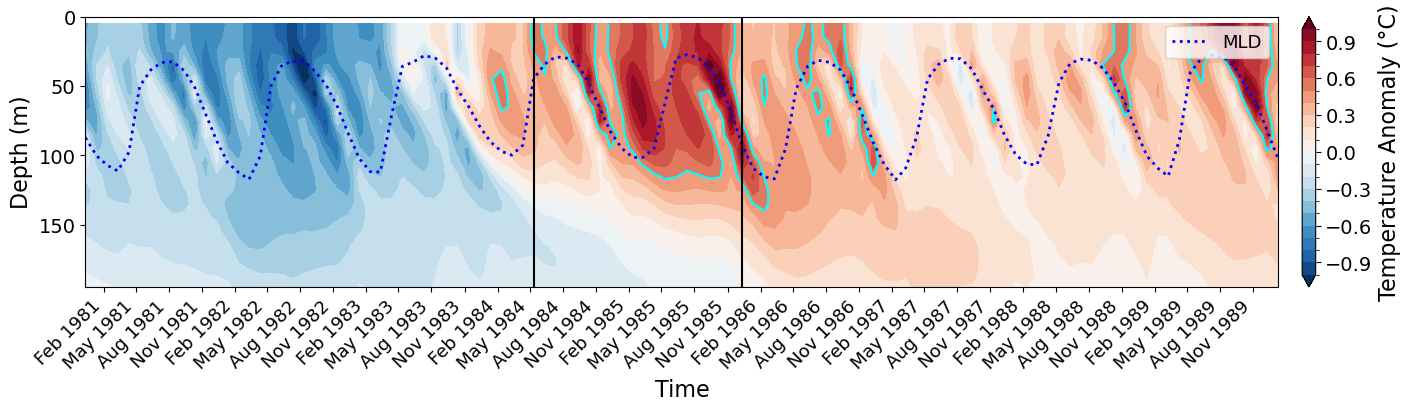

In [37]:
fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)

# Get the data
data = anomalies_region_nan[:, :].sel(time=slice('2010-12', '2020-01')).mean(dim=('lat', 'lon')).transpose()
data["z_t"] = data["z_t"] / 100
data["z_t"].attrs["units"] = "m"

# Filled contour
contour = data.plot.contourf(
    ax=ax,
    levels=np.linspace(-1., 1., 21),
    vmin=-1., vmax=1.,
    cmap='RdBu_r',
    add_colorbar=False,
    extend='both'
)

# Contour lines (threshold outline)
contour_lines = data.plot.contour(
    ax=ax,
    levels=np.linspace(0.5, 1.5, 2),
    vmin=0.5, vmax=1.5,
    colors='cyan',
    add_colorbar=False,
    extend=False
)

# Colorbar
cbar = plt.colorbar(contour, ax=ax, pad=0.02)
cbar.set_label('Temperature Anomaly (°C)', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Axes formatting
ax.invert_yaxis()
ax.set_ylabel('Depth (m)', fontsize=16)
ax.set_xlabel('Time', fontsize=16)
ax.set_title('')  # xarray auto-title tends to be tiny/redundant; drop or replace explicitly

# --- Month-level x-axis formatting ---
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # tick every 3 months; use interval=1 for every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))   # e.g. "Jan 2015"
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=13)

ax.tick_params(axis='y', labelsize=14)

# Reference lines
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

mld_ts = mld_region_nan.mean(dim=('lat', 'lon')).sel(time=slice('2010-12', '2020-01'))
ax.plot(mld_ts.time, mld_ts, c='blue', linestyle='dotted', linewidth=2, label='MLD')

ax.axvline(x=features.time.sel(time='2014-05').item(), c='k', linewidth=1.5)
ax.axvline(x=features.time.sel(time='2015-12').item(), c='k', linewidth=1.5)

ax.legend(fontsize=13, loc='upper right')

ax.set_ylim(195, 0)

plt.show()